## Mini-Project 3: Lake Victoria Fish Stock & Export Risk Model

**Scenario.** A fish-export cooperative in Jinja wants to know whether its harvesting rate is sustainable and how risky its revenue is.



This notebook uses the `FishStock`, `PriceModel` and `RiskAssessor` classes defined in `src/project3_fish_stock.py`.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import statistics

sys.path.insert(0, "../src")
from project3_fish_stock import FishStock, PriceModel, RiskAssessor
from utils import fibonacci

np.random.seed(42)

### Task 1: Fibonacci baseline (and why it is biologically unrealistic)

Unbounded Fibonacci growth has no carrying capacity: each number keeps growing forever by a fixed rule, unrelated to food, space or predation limits. A real fish population cannot expand without bound - it is constrained by the lake's environment, so growth must slow and eventually plateau near some maximum sustainable size. Fibonacci numbers also have no way to represent harvesting removing fish from the stock. This is why the logistic growth model (with a carrying capacity K and a harvest term) used below is far more defensible than treating "stock" as a Fibonacci sequence.

In [2]:
fibonacci_baseline = fibonacci(15)
print("15 Fibonacci numbers used as a naive 'stock' baseline:")
print(fibonacci_baseline)
print(f"Ratio of last two numbers: {fibonacci_baseline[-1] / fibonacci_baseline[-2]:.3f} "
      "(keeps climbing forever - no ceiling, unlike a real fish stock)")

15 Fibonacci numbers used as a naive 'stock' baseline:
[1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610]
Ratio of last two numbers: 1.618 (keeps climbing forever - no ceiling, unlike a real fish stock)


### Tasks 2-3: logistic fish stock, price random walk, weekly revenue

Base scenario: r=0.4, K=10,000 tonnes, N(0)=4,000 tonnes, harvest rate h=0.10, simulated for 52 weeks. Price starts at UGX 12,000/kg and is bounded to [9,000, 16,000].

In [3]:
WEEKS = 52
BASE_HARVEST_RATE = 0.10

fish_stock = FishStock(r=0.4, k=10_000, n0=4_000, harvest_rate=BASE_HARVEST_RATE)
stock_trajectory = fish_stock.simulate(WEEKS)
harvest_tonnes = fish_stock.harvested_amounts(stock_trajectory)
harvest_kg = harvest_tonnes * 1000

price_model = PriceModel(start_price=12_000, low=9_000, high=16_000, seed=42)
price_path = price_model.simulate(WEEKS)
weekly_prices = price_path[:-1]

weekly_revenue = harvest_kg * weekly_prices

print(f"Final stock after {WEEKS} weeks: {stock_trajectory[-1]:.1f} tonnes")
print(f"Total harvested: {harvest_tonnes.sum():.1f} tonnes")
print(f"Total revenue: UGX {weekly_revenue.sum():,.0f}")

Final stock after 52 weeks: 7500.0 tonnes
Total harvested: 37362.5 tonnes
Total revenue: UGX 454,199,188,414


### Task 4: Revenue statistics and why a raw variance threshold is meaningless

Variance is in UGX-squared, an unusable unit. The coefficient of variation (CV = stdev / mean) is unitless and comparable across scales - it is the sound way to judge how "risky" this revenue stream is.

In [4]:
revenue_mean = statistics.mean(weekly_revenue)
revenue_median = statistics.median(weekly_revenue)
revenue_variance = statistics.variance(weekly_revenue)
revenue_stdev = statistics.stdev(weekly_revenue)
revenue_cv = revenue_stdev / revenue_mean

print(f"Mean weekly revenue:     UGX {revenue_mean:,.0f}")
print(f"Median weekly revenue:   UGX {revenue_median:,.0f}")
print(f"Variance (UGX^2):        {revenue_variance:,.0f}  <- units are meaningless on their own")
print(f"Std dev (UGX):           {revenue_stdev:,.0f}")
print(f"Coefficient of variation: {revenue_cv:.3f}  <- unitless, comparable across scales")

Mean weekly revenue:     UGX 8,734,599,777
Median weekly revenue:   UGX 8,909,306,991
Variance (UGX^2):        1,215,715,840,879,019,008  <- units are meaningless on their own
Std dev (UGX):           1,102,595,048
Coefficient of variation: 0.126  <- unitless, comparable across scales


### Task 5: Risk classification and Monte Carlo 5% Value-at-Risk

At least 1,000 simulated price paths are used to build a distribution of annual revenue for the base h=0.10 scenario.

In [5]:
risk_assessor = RiskAssessor()
base_revenues = risk_assessor.monte_carlo_annual_revenue(
    fish_stock, price_model, weeks=WEEKS, n_paths=1000, seed=7
)

base_risk_class = risk_assessor.classify(base_revenues)
base_var = risk_assessor.value_at_risk(base_revenues, confidence=0.95)

print(f"Simulated annual revenue over 1,000 price paths (h={BASE_HARVEST_RATE}):")
print(f"  mean = UGX {base_revenues.mean():,.0f}")
print(f"  CV = {risk_assessor.coefficient_of_variation(base_revenues):.3f}")
print(f"  risk class = {base_risk_class}")
print(f"  5% Value-at-Risk = UGX {base_var:,.0f} "
      "(only 5% of simulated years fall below this)")

Simulated annual revenue over 1,000 price paths (h=0.1):
  mean = UGX 448,633,734,863
  CV = 0.101
  risk class = Low risk
  5% Value-at-Risk = UGX 377,202,553,637 (only 5% of simulated years fall below this)


### Task 6: Scenario analysis vs Maximum Sustainable Yield (MSY = rK/4)

In [6]:
harvest_rates = [0.05, 0.10, 0.20, 0.30]
scenario_stocks = {}
scenario_rows = []

msy = fish_stock.maximum_sustainable_yield()
print(f"Theoretical MSY = {msy:.1f} tonnes/week\n")

for h in harvest_rates:
    fs = FishStock(r=0.4, k=10_000, n0=4_000, harvest_rate=h)
    traj = fs.simulate(WEEKS)
    scenario_stocks[h] = traj
    revenues_h = risk_assessor.monte_carlo_annual_revenue(fs, price_model, weeks=WEEKS, n_paths=500, seed=7)
    row = {
        "harvest_rate": h,
        "final_stock_t": traj[-1],
        "mean_annual_revenue_ugx": revenues_h.mean(),
        "risk_class": risk_assessor.classify(revenues_h),
    }
    scenario_rows.append(row)
    print(f"h={h}: final stock={row['final_stock_t']:.1f} t, "
          f"mean revenue=UGX {row['mean_annual_revenue_ugx']:,.0f}, risk={row['risk_class']}")

Theoretical MSY = 1000.0 tonnes/week

h=0.05: final stock=8750.0 t, mean revenue=UGX 261,326,401,971, risk=Low risk


h=0.1: final stock=7500.0 t, mean revenue=UGX 449,637,592,440, risk=Low risk
h=0.2: final stock=5000.0 t, mean revenue=UGX 612,182,343,520, risk=Low risk


h=0.3: final stock=2503.7 t, mean revenue=UGX 510,872,349,720, risk=Low risk


### Task 7: Stock trajectories and annual revenue distribution with VaR

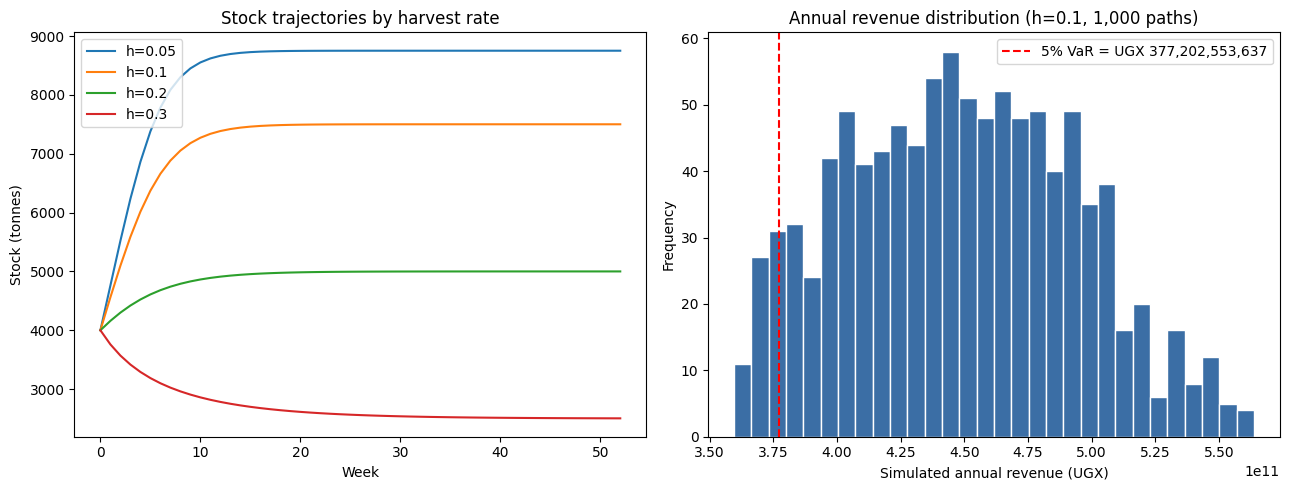

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

weeks_axis = np.arange(WEEKS + 1)
for h, traj in scenario_stocks.items():
    ax1.plot(weeks_axis, traj, label=f"h={h}")
ax1.set_xlabel("Week")
ax1.set_ylabel("Stock (tonnes)")
ax1.set_title("Stock trajectories by harvest rate")
ax1.legend()

ax2.hist(base_revenues, bins=30, color="#3b6ea5", edgecolor="white")
ax2.axvline(base_var, color="red", linestyle="--", label=f"5% VaR = UGX {base_var:,.0f}")
ax2.set_xlabel("Simulated annual revenue (UGX)")
ax2.set_ylabel("Frequency")
ax2.set_title(f"Annual revenue distribution (h={BASE_HARVEST_RATE}, 1,000 paths)")
ax2.legend()

plt.tight_layout()
plt.show()

## Findings & Limitations

At the base harvest rate (h=0.10), the stock settles at 7,500 tonnes (below K=10,000, as expected once harvesting offsets growth) and the coefficient of variation of weekly revenue is only 0.126, with a 5% Monte Carlo Value-at-Risk of about UGX 377 billion against a mean annual revenue of about UGX 449 billion - both point to a "Low risk" classification by our CV rule. The scenario analysis shows a non-monotonic pattern: mean revenue rises from h=0.05 to a peak around h=0.20 (final stock 5,000 tonnes, close to K/2, the classic MSY stock level), then falls at h=0.30 as the stock nearly collapses to about 2,500 tonnes. This lines up neatly with theory: MSY harvesting occurs near h = r/2 = 0.20 for this logistic model, and pushing past it (h=0.30) destroys more stock than it gains in short-term revenue - a textbook overfishing outcome. The 15-number Fibonacci baseline, in contrast, would have kept "growing" without ever reflecting this trade-off, which is exactly why it was replaced.

**Limitations:** the illustrative parameters (K=10,000 tonnes, weekly harvest, kg-scale prices) produce revenue figures in the hundreds of billions of UGX, which is far larger than a real Jinja cooperative's turnover - the model is a reasonable teaching illustration of logistic dynamics and risk methodology, not a calibrated real financial forecast. The risk classifier's CV thresholds (0.15 / 0.35) are also a simplifying assumption rather than an industry-validated risk standard, and the price random walk ignores real seasonal/export-market effects.